In [26]:
import pandas as pd

df= pd.read_csv("ai_student_impact_dataset.csv")

info=df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

ossevare corr votazione, incremento, skill retention e burnout
Major_Category -> più colonne?
Year_of_Study -> diventa int 
Primary_Use_Case -> più colonne?
Prompt_Engineering_Skill -> int
Institutional_Policy -> int


In [27]:
df["GPA_increment"] = df["Post_Semester_GPA"]- df["Pre_Semester_GPA"]

In [28]:
df.value_counts(df["Burnout_Risk_Level"])
trad={"Low":1,"Medium":2,"High":3}
df["Burnout_Risk_Level"]=df["Burnout_Risk_Level"].map(trad)

In [29]:
df[["Burnout_Risk_Level","GPA_increment","Post_Semester_GPA","Skill_Retention_Score"]].corr()

,Burnout_Risk_Level,GPA_increment,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,1.000000,-0.006818,-0.095543,-0.058140
GPA_increment,-0.006818,1.000000,0.277146,0.195833
Post_Semester_GPA,-0.095543,0.277146,1.000000,0.169616
Skill_Retention_Score,-0.058140,0.195833,0.169616,1.000000


togliamo ora il target e info su Burnout e Skill Retention

In [30]:
y= df["GPA_increment"].copy()
df.drop(columns=["Burnout_Risk_Level","Skill_Retention_Score"], inplace=True)

In [31]:
df.drop(columns="Student_ID",inplace=True)

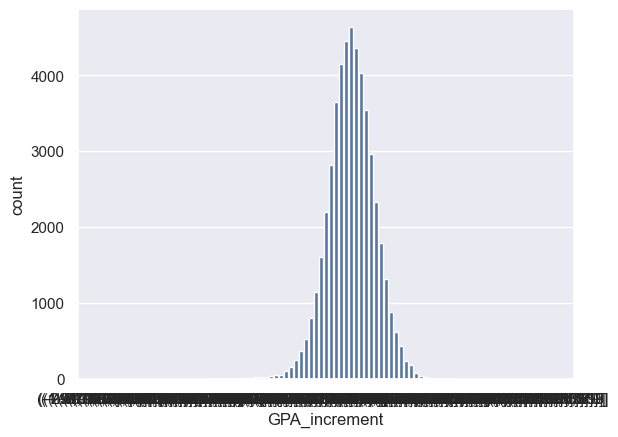

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

gruppi = pd.cut(y, np.linspace(-2,2,100))

sns.countplot(x=gruppi)
plt.show()


In [33]:
df.value_counts(df["Major_Category"])

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

fare modelli diversi per percorsi diversi?

In [34]:
trad={
"Junior": 3 ,
"Freshman" : 1,
"Senior"  : 4, 
"Sophomore"  : 2,
"Graduate" : 5,
}

df["Year_of_Study"]=df["Year_of_Study"].map(trad)

print(df["Year_of_Study"].unique())

[4 3 1 2 5]


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  str    
 1   Year_of_Study               50000 non-null  int64  
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  str    
 5   Prompt_Engineering_Skill    50000 non-null  str    
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  str    
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  GPA_increment               50000 non-null

In [36]:
for corso in df["Primary_Use_Case"].unique():
    df["is_"+corso]= df["Primary_Use_Case"]==corso

df.drop(columns="Primary_Use_Case",inplace=True)

In [37]:
df.value_counts(df["Prompt_Engineering_Skill"])

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [38]:
trad={
"Beginner": 1 ,
"Intermediate" : 2,
"Advanced"  : 3, 
}

df["Prompt_Engineering_Skill"]=df["Prompt_Engineering_Skill"].map(trad)

print(df["Prompt_Engineering_Skill"].unique())

[1 3 2]


In [39]:

df.value_counts(df["Institutional_Policy"])

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [40]:
for corso in df["Institutional_Policy"].unique():
    df["is_"+corso]= df["Institutional_Policy"]==corso

df.drop(columns="Institutional_Policy",inplace=True)

primo approccio mantenere categorie tutte assieme nello stesso dataset ma in colonne diverse e vediamo (poi dopo proviamo a dividere dataset per fare 5 modelli diversi)

In [41]:
df_by_category = df.copy() #salvo una copia del dataset per poi usarlo dopo per creare modelli separati

In [42]:
for corso in df["Major_Category"].unique():
    df["major_is_"+corso]= df["Major_Category"]==corso

df.drop(columns="Major_Category",inplace=True)

In [43]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
df.drop(columns="GPA_increment",inplace=True,errors=True)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

modello baseline

In [44]:
from xgboost import XGBRegressor

rf_model = XGBRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train) 

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
predictions = rf_model.predict(X_test)

print(mean_absolute_error(y_test, predictions))

print(r2_score(y_test, predictions))

0.013894464762454643
0.988228633127005


In [46]:
# un dataframe per ogni categoria
df_dict={
    k:df_by_category[df_by_category["Major_Category"] == k]  for k in df_by_category["Major_Category"].unique()
}


In [47]:
for d in df_dict.values():
    d.drop(columns=["Major_Category"], inplace=True)
    d.drop(columns=["GPA_increment"], inplace=True)
d.info()


<class 'pandas.DataFrame'>
Index: 5933 entries, 7 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year_of_Study                 5933 non-null   int64  
 1   Pre_Semester_GPA              5933 non-null   float64
 2   Weekly_GenAI_Hours            5933 non-null   float64
 3   Prompt_Engineering_Skill      5933 non-null   int64  
 4   Tool_Diversity                5933 non-null   int64  
 5   Paid_Subscription             5933 non-null   bool   
 6   Traditional_Study_Hours       5933 non-null   float64
 7   Perceived_AI_Dependency       5933 non-null   int64  
 8   Anxiety_Level_During_Exams    5933 non-null   int64  
 9   Post_Semester_GPA             5933 non-null   float64
 10  is_Copywriting/Drafting       5933 non-null   bool   
 11  is_Ideation                   5933 non-null   bool   
 12  is_Summarizing_Reading        5933 non-null   bool   
 13  is_Debugging/Troub

In [48]:
model_params_major_dict={}

import optuna

def objective(trial):

    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'enable_categorical':True,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'bootstrap_type': "Bayesian",
        
       
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3,18),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif params["bootstrap_type"] == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    model = XGBRegressor(**params)

    model.fit(X_train, y_train,verbose=1)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


In [49]:
best_model_major_dict={}
import seaborn as sns
for corso in df_dict.keys():
    
    print(f"major {corso}")
    c=corso

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    
    optimal_params = study.best_trial.params
    model_params_major_dict[corso]=optimal_params
    model=XGBRegressor(**optimal_params)
    data= df_dict[corso]
    y=data["Post_Semester_GPA"]
    X=data.drop(columns='Post_Semester_GPA')

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train,y_train)
    preds = model.predict(X_test)

    print("business mae:", mean_absolute_error(y_test, preds))
    print("business r2:", r2_score(y_test, preds))
    best_model_major_dict[corso]=model







    


[I 2026-06-05 09:27:50,428] A new study created in memory with name: no-name-f9bd59ee-1c7e-4860-ba8c-5b3ef91492e3


major Humanities


[I 2026-06-05 09:27:50,810] Trial 0 finished with value: 0.1650411049984526 and parameters: {'n_estimators': 60, 'learning_rate': 0.025360439841207165, 'max_depth': 15, 'subsample': 0.8128435815189433, 'colsample_bytree': 0.9627482649226267, 'reg_alpha': 0.002650578028215608, 'bagging_temperature': 2.247008398160756}. Best is trial 0 with value: 0.1650411049984526.
[I 2026-06-05 09:27:50,958] Trial 1 finished with value: 0.1495254136963807 and parameters: {'n_estimators': 154, 'learning_rate': 0.012585679025904621, 'max_depth': 8, 'subsample': 0.6808149937524796, 'colsample_bytree': 0.8376742051015222, 'reg_alpha': 0.12292768099941889, 'bagging_temperature': 9.646014648236319}. Best is trial 1 with value: 0.1495254136963807.
[I 2026-06-05 09:27:51,066] Trial 2 finished with value: 0.3391691733766281 and parameters: {'n_estimators': 233, 'learning_rate': 0.0010986153422009376, 'max_depth': 4, 'subsample': 0.7062464450720712, 'colsample_bytree': 0.8996698478428931, 'reg_alpha': 0.0034012

Number of finished trials: 100
Best trial:
  Value: 0.1148118350313806
  Params: 
    n_estimators: 140
    learning_rate: 0.08214176077331509
    max_depth: 4
    subsample: 0.7506531631799435
    colsample_bytree: 0.6701822953468177
    reg_alpha: 0.002706715835090601
    bagging_temperature: 0.32385779103293055
business mae: 0.11551441992778311
business r2: 0.91525193245372
major Medical


[I 2026-06-05 09:28:01,261] Trial 0 finished with value: 0.17725234610651744 and parameters: {'n_estimators': 232, 'learning_rate': 0.00633442888211134, 'max_depth': 13, 'subsample': 0.6505711899586871, 'colsample_bytree': 0.8869821008075961, 'reg_alpha': 0.4596251963527409, 'bagging_temperature': 0.12028061868575635}. Best is trial 0 with value: 0.17725234610651744.
[I 2026-06-05 09:28:01,773] Trial 1 finished with value: 0.1305502347526727 and parameters: {'n_estimators': 168, 'learning_rate': 0.03148213060124009, 'max_depth': 13, 'subsample': 0.6994671743938907, 'colsample_bytree': 0.9177831975242858, 'reg_alpha': 0.0010752153120936214, 'bagging_temperature': 6.9620955158910816}. Best is trial 1 with value: 0.1305502347526727.
[I 2026-06-05 09:28:01,864] Trial 2 finished with value: 0.11653249506376408 and parameters: {'n_estimators': 225, 'learning_rate': 0.07032317117228004, 'max_depth': 7, 'subsample': 0.8592236576396262, 'colsample_bytree': 0.6614633339366982, 'reg_alpha': 4.170

Number of finished trials: 100
Best trial:
  Value: 0.11531203337657597
  Params: 
    n_estimators: 235
    learning_rate: 0.07680470585233132
    max_depth: 3
    subsample: 0.8570120946869755
    colsample_bytree: 0.8587871314011555
    reg_alpha: 0.16005910713480032
    bagging_temperature: 1.5031904096128912
business mae: 0.11601394271409071
business r2: 0.9149963069374899
major Business


[I 2026-06-05 09:28:13,205] Trial 0 finished with value: 0.129972541642151 and parameters: {'n_estimators': 144, 'learning_rate': 0.02205904744854542, 'max_depth': 15, 'subsample': 0.7089724873163803, 'colsample_bytree': 0.9959489631064681, 'reg_alpha': 0.00963841435276845, 'bagging_temperature': 9.749710808586705}. Best is trial 0 with value: 0.129972541642151.
[I 2026-06-05 09:28:13,244] Trial 1 finished with value: 0.202615774142495 and parameters: {'n_estimators': 97, 'learning_rate': 0.0109540159297046, 'max_depth': 3, 'subsample': 0.6825133281235698, 'colsample_bytree': 0.917946598602828, 'reg_alpha': 0.023289437339715637, 'bagging_temperature': 6.957174856645568}. Best is trial 0 with value: 0.129972541642151.
[I 2026-06-05 09:28:13,298] Trial 2 finished with value: 0.2565688209579322 and parameters: {'n_estimators': 148, 'learning_rate': 0.0054574032743481835, 'max_depth': 4, 'subsample': 0.6569863628867008, 'colsample_bytree': 0.6770130663346489, 'reg_alpha': 3.047602156566215

Number of finished trials: 100
Best trial:
  Value: 0.11537787515504887
  Params: 
    n_estimators: 134
    learning_rate: 0.1366818102634167
    max_depth: 4
    subsample: 0.9847739968874484
    colsample_bytree: 0.6002911852235744
    reg_alpha: 1.033826698257931
    bagging_temperature: 0.9476829117844163
business mae: 0.1158458501106244
business r2: 0.9070991428101353
major STEM


[I 2026-06-05 09:28:24,319] Trial 1 finished with value: 0.28760335055005504 and parameters: {'n_estimators': 222, 'learning_rate': 0.002756064356177754, 'max_depth': 8, 'subsample': 0.9556758323774492, 'colsample_bytree': 0.6995772650662553, 'reg_alpha': 0.2734219278786404, 'bagging_temperature': 6.581313879898351}. Best is trial 0 with value: 0.18605640776192206.
[I 2026-06-05 09:28:24,542] Trial 2 finished with value: 0.2648088846865245 and parameters: {'n_estimators': 144, 'learning_rate': 0.003698269958356704, 'max_depth': 10, 'subsample': 0.9019652286181363, 'colsample_bytree': 0.9688522259469191, 'reg_alpha': 0.2271340427131969, 'bagging_temperature': 4.090098132569105}. Best is trial 0 with value: 0.18605640776192206.
[I 2026-06-05 09:28:25,429] Trial 3 finished with value: 0.13940008163927087 and parameters: {'n_estimators': 121, 'learning_rate': 0.09768563797711566, 'max_depth': 17, 'subsample': 0.6882535584171129, 'colsample_bytree': 0.7341649485497608, 'reg_alpha': 0.019624

Number of finished trials: 100
Best trial:
  Value: 0.11672785325702602
  Params: 
    n_estimators: 239
    learning_rate: 0.05483450252413244
    max_depth: 5
    subsample: 0.7439413232537899
    colsample_bytree: 0.8758384510540854
    reg_alpha: 2.5451652662533366
    bagging_temperature: 4.025962569534492
business mae: 0.11664410586851051
business r2: 0.906776137552511
major Arts


[I 2026-06-05 09:28:38,113] Trial 0 finished with value: 0.14974705767531102 and parameters: {'n_estimators': 149, 'learning_rate': 0.027225685889244296, 'max_depth': 18, 'subsample': 0.9214396783984946, 'colsample_bytree': 0.6635818249766069, 'reg_alpha': 0.38232197556550773, 'bagging_temperature': 0.15090985849181449}. Best is trial 0 with value: 0.14974705767531102.
[I 2026-06-05 09:28:38,147] Trial 1 finished with value: 0.28091714552901026 and parameters: {'n_estimators': 96, 'learning_rate': 0.007579987968656608, 'max_depth': 3, 'subsample': 0.965974450343756, 'colsample_bytree': 0.6913436394968228, 'reg_alpha': 0.09710714130719182, 'bagging_temperature': 9.384540353397504}. Best is trial 0 with value: 0.14974705767531102.
[I 2026-06-05 09:28:38,179] Trial 2 finished with value: 0.12143710900477833 and parameters: {'n_estimators': 100, 'learning_rate': 0.17476482114070765, 'max_depth': 4, 'subsample': 0.8626696743406252, 'colsample_bytree': 0.9484147550358923, 'reg_alpha': 0.1051

Number of finished trials: 100
Best trial:
  Value: 0.1181630188131292
  Params: 
    n_estimators: 180
    learning_rate: 0.10651489703776178
    max_depth: 3
    subsample: 0.8885436083910419
    colsample_bytree: 0.9109545601093787
    reg_alpha: 1.8779332930609336
    bagging_temperature: 7.083717730475498
business mae: 0.11819299793645123
business r2: 0.9141285536980415


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Humanities mae: 0.11551441992778311
Humanities r2: 0.91525193245372
Medical mae: 0.11601394271409071
Medical r2: 0.9149963069374899


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Business mae: 0.1158458501106244
Business r2: 0.9070991428101353


c:\Users\gabri\Desktop\Finale\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "bagging_temperature" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


STEM mae: 0.11664410586851051
STEM r2: 0.906776137552511
Arts mae: 0.11819299793645123
Arts r2: 0.9141285536980415


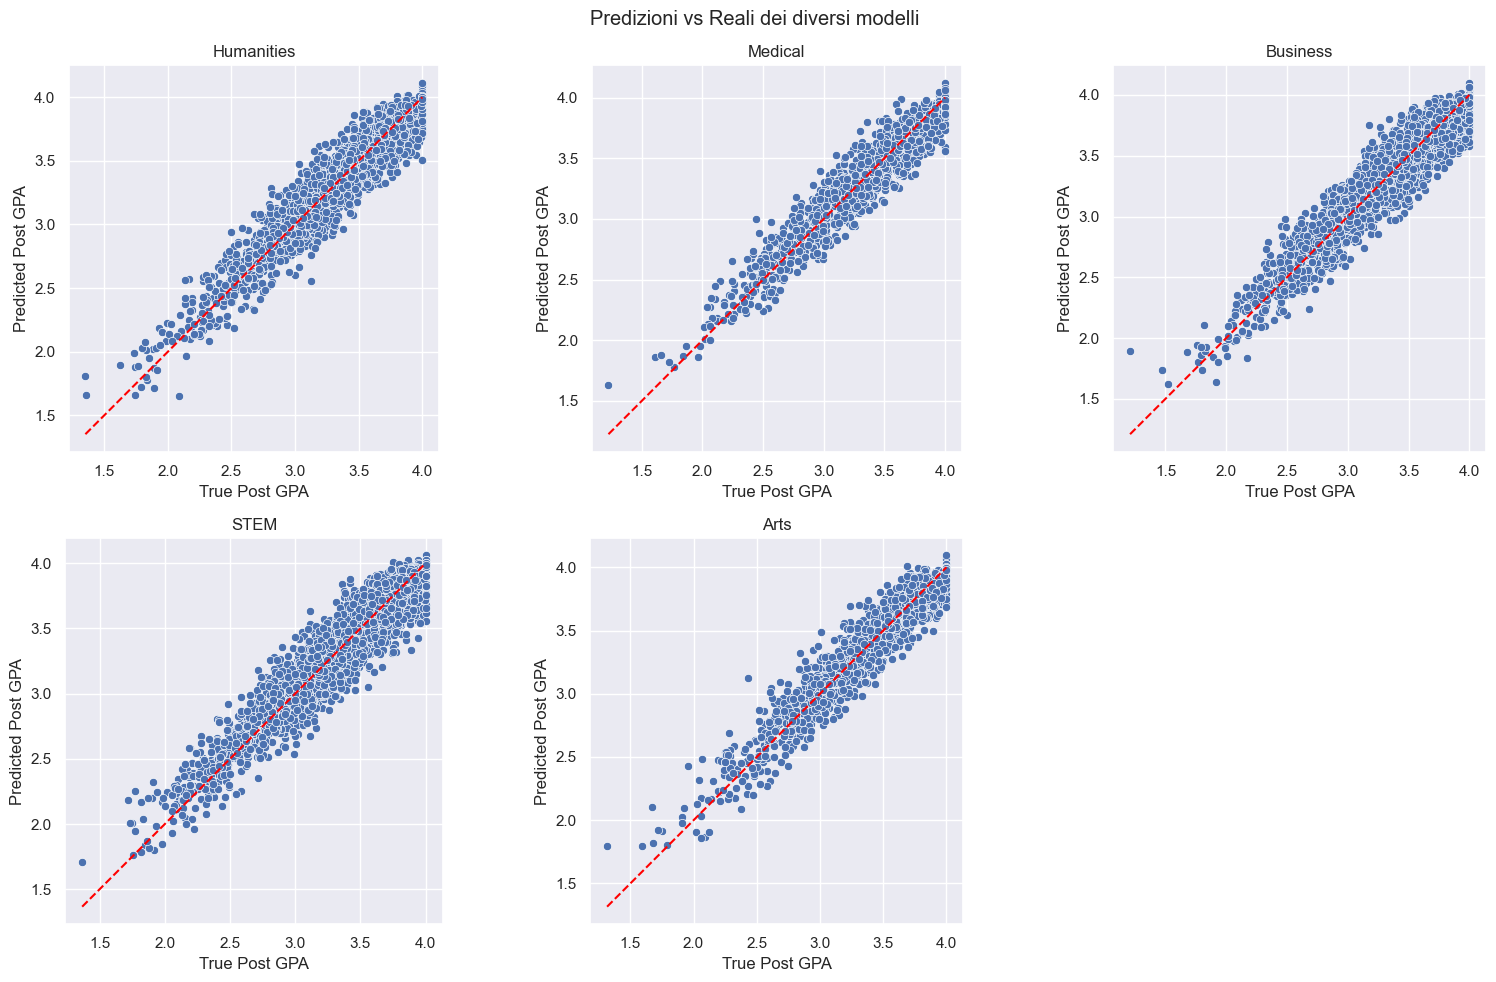

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
sns.set_theme(style='darkgrid')

for i, corso in enumerate(df_dict):
    optimal_params = model_params_major_dict[corso]

    model = XGBRegressor(**optimal_params)

    data = df_dict[corso]

    y = data["Post_Semester_GPA"]
    X = data.drop(columns="Post_Semester_GPA")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    print(f"{corso} mae:", mean_absolute_error(y_test, preds))
    print(f"{corso} r2:", r2_score(y_test, preds))

    sns.scatterplot(
        x=y_test,
        y=preds,
        ax=axes[i]
    )

    axes[i].set_title(corso)
    axes[i].set_xlabel("True Post GPA")
    axes[i].set_ylabel("Predicted Post GPA")
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],c='red', linestyle='--',)

    

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Predizioni vs Reali dei diversi modelli")
plt.tight_layout()
plt.show()